# 01 EDA: Stellar Classification (SDSS17)

## 1. Импорты и чтение данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
ROOT = Path.cwd()
if not (ROOT / 'data' / 'raw' / 'star_classification.csv').exists():
    ROOT = ROOT.parent
RAW_PATH = ROOT / 'data' / 'raw' / 'star_classification.csv'

df = pd.read_csv(RAW_PATH, dtype={'obj_ID': 'string', 'spec_obj_ID': 'string'})
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1237660961327743232,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6543777369295181824,GALAXY,0.634794,5812,56354,171
1,1237664879951151360,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,11760142036707334144,GALAXY,0.779136,10445,58158,427
2,1237660961330430208,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5152200256025548800,GALAXY,0.644195,4576,55592,299
3,1237663478724297984,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,10301071412954421248,GALAXY,0.932346,9149,58039,775
4,1237680272041378048,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6891864880783316992,GALAXY,0.116123,6121,56187,842


## 2. Базовая проверка: типы, пропуски, дубли

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  string 
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  string 
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(8), int64(7), str(1), str

In [4]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Series([], dtype: int64)

In [5]:
exact_duplicates = df.duplicated().sum()
obj_id_duplicates = df.duplicated(subset=['obj_ID']).sum()
spec_obj_id_duplicates = df.duplicated(subset=['spec_obj_ID']).sum()

print(f'Exact duplicates: {exact_duplicates}')
print(f'Duplicates by obj_ID: {obj_id_duplicates}')
print(f'Duplicates by spec_obj_ID: {spec_obj_id_duplicates}')
print('Note: we do not drop rows by obj_ID in preprocessing; only exact row duplicates are removed.')

Exact duplicates: 0
Duplicates by obj_ID: 19154
Duplicates by spec_obj_ID: 0
Note: we do not drop rows by obj_ID in preprocessing; only exact row duplicates are removed.


## 3. Целевая переменная и дисбаланс классов

In [6]:
class_counts = df['class'].value_counts()
class_share = (class_counts / len(df) * 100).round(2)

print(class_counts)
print('\nClass share (%):')
print(class_share)

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

Class share (%):
class
GALAXY    59.44
STAR      21.59
QSO       18.96
Name: count, dtype: float64


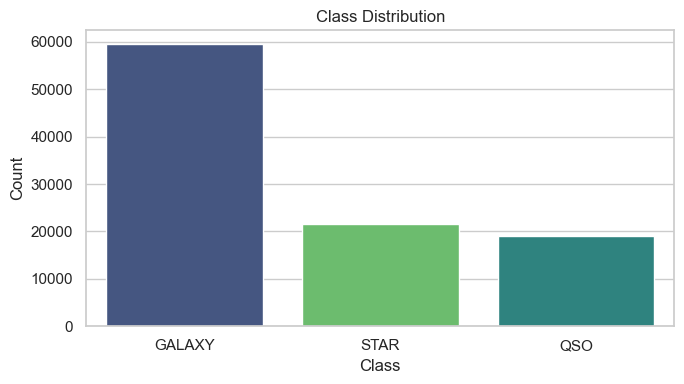

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='class', hue='class', order=df['class'].value_counts().index, palette='viridis', legend=False)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Работа с признаками и feature engineering

In [8]:
work_df = df.copy()

# Простые астрономические цветовые индексы
work_df['u_g'] = work_df['u'] - work_df['g']
work_df['g_r'] = work_df['g'] - work_df['r']
work_df['r_i'] = work_df['r'] - work_df['i']
work_df['i_z'] = work_df['i'] - work_df['z']

work_df[['u_g', 'g_r', 'r_i', 'i_z']].describe()

,u_g,g_r,r_i,i_z
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.449081,0.885625,0.560908,0.416044
std,1.179335,31.688694,0.501517,31.678379
min,-12.748140,-10017.165600,-14.649070,-13.162490
25%,0.631215,0.379798,0.216317,0.134500
50%,1.321670,0.931450,0.479795,0.338040
75%,2.044558,1.577983,0.892192,0.474080
max,18.624950,14.315170,12.205800,10017.016750


## 5. Визуализации распределений и зависимостей

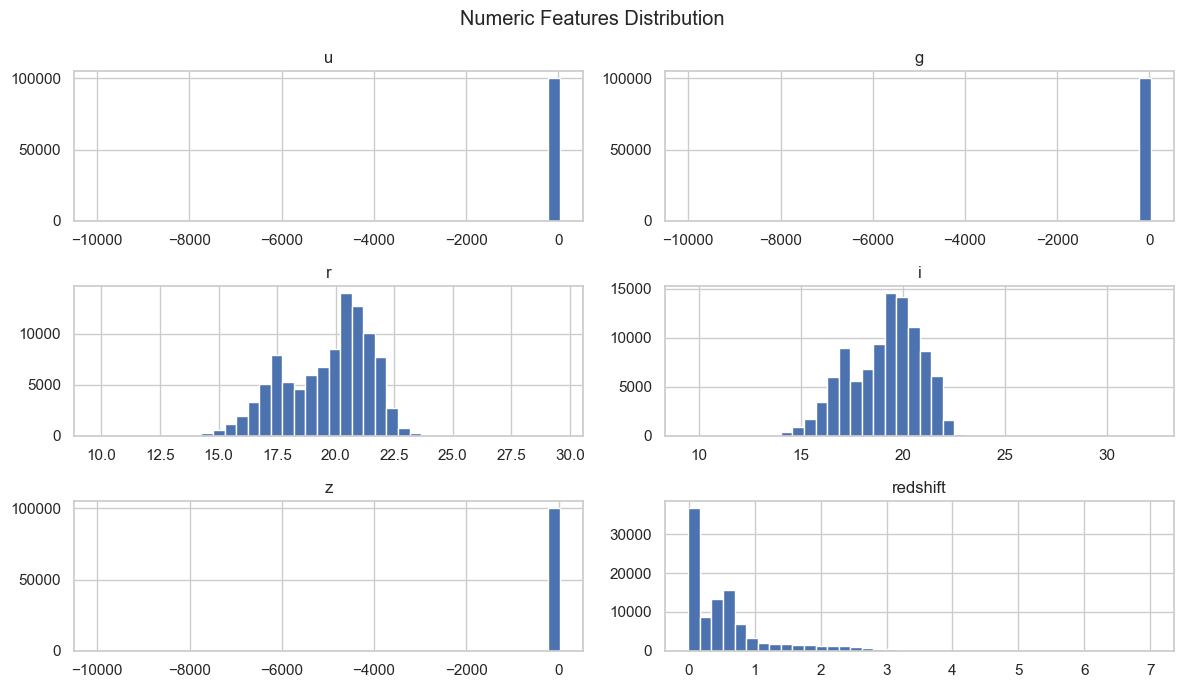

In [9]:
plot_columns = ['u', 'g', 'r', 'i', 'z', 'redshift']
work_df[plot_columns].hist(figsize=(12, 7), bins=40)
plt.suptitle('Numeric Features Distribution')
plt.tight_layout()
plt.show()

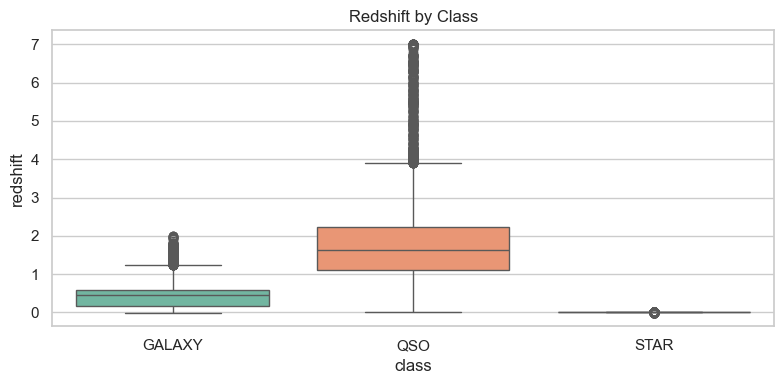

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=work_df, x='class', y='redshift', hue='class', palette='Set2', legend=False)
plt.title('Redshift by Class')
plt.tight_layout()
plt.show()

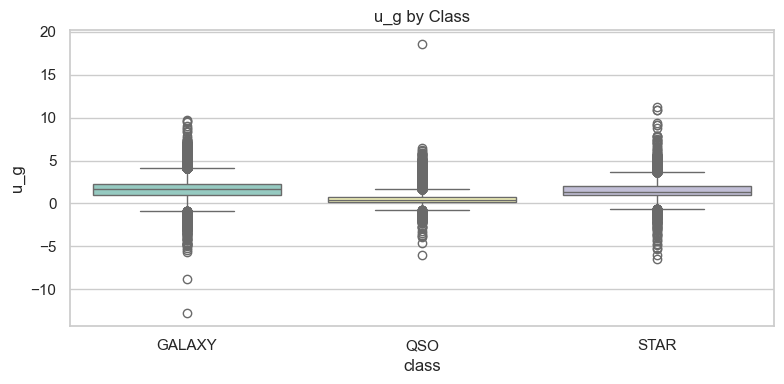

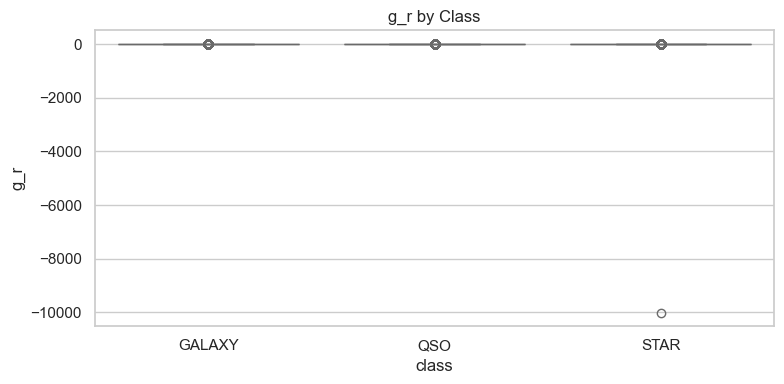

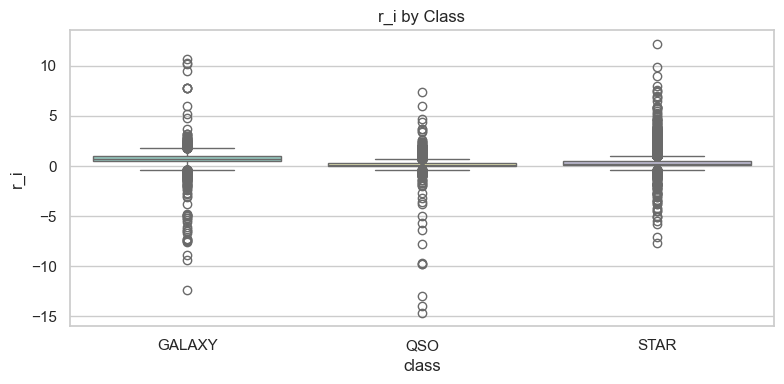

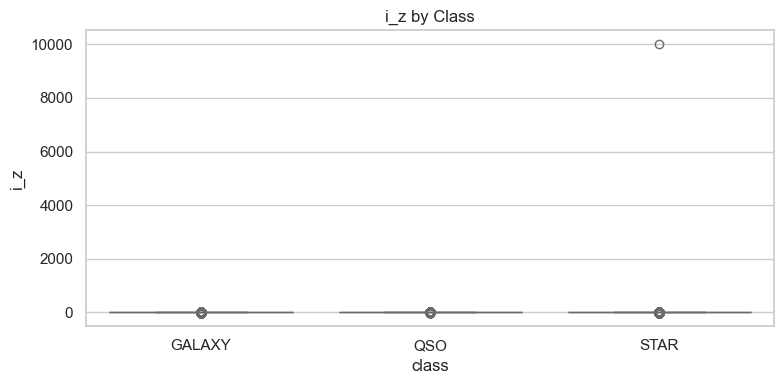

In [11]:
for col in ['u_g', 'g_r', 'r_i', 'i_z']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=work_df, x='class', y=col, hue='class', palette='Set3', legend=False)
    plt.title(f'{col} by Class')
    plt.tight_layout()
    plt.show()

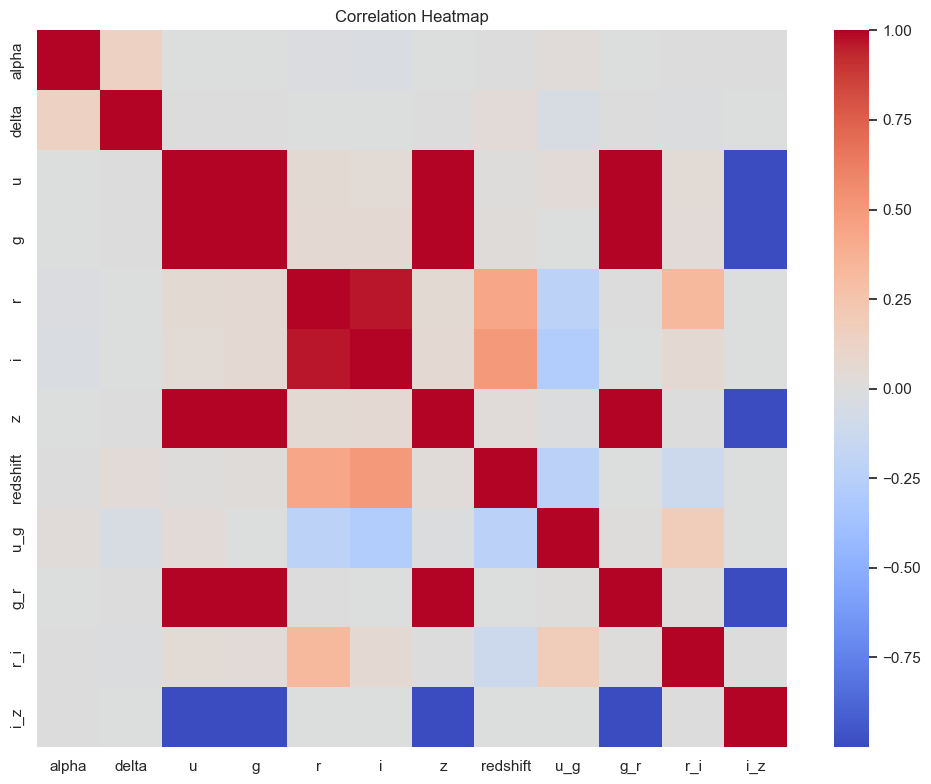

In [12]:
corr_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z']
corr = work_df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6. Черновая проверка preprocessing pipeline из src

In [13]:
import sys
sys.path.append(str(ROOT))

from src.preprocessing import clean_data, select_model_columns, add_engineered_features, split_data

clean_df = clean_data(df)
model_df = add_engineered_features(select_model_columns(clean_df))
train_df, val_df, test_df = split_data(model_df, random_state=42)

print('Clean shape:', clean_df.shape)
print('Model shape:', model_df.shape)
print('Split sizes:', len(train_df), len(val_df), len(test_df))

Clean shape: (100000, 18)
Model shape: (100000, 13)
Split sizes: 69999 15000 15001


In [14]:
for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{name.upper()} class distribution:')
    print(part['class'].value_counts(normalize=True).round(3))


TRAIN class distribution:
class
GALAXY    0.594
STAR      0.216
QSO       0.190
Name: proportion, dtype: float64

VAL class distribution:
class
GALAXY    0.594
STAR      0.216
QSO       0.190
Name: proportion, dtype: float64

TEST class distribution:
class
GALAXY    0.594
STAR      0.216
QSO       0.190
Name: proportion, dtype: float64


## Вывод

Датасет достаточно большой для задачи классификации: 100000 строк и 18 признаков. Пропусков нет, точных дублей нет. При этом найдено 19154 повторения `obj_ID`, но они не удалялись, так как это не полные дубли строк и могут отражать повторные наблюдения объекта.

Классы распределены неравномерно: `GALAXY` ≈ 59.44%, `STAR` ≈ 21.59%, `QSO` ≈ 18.96%, поэтому для оценки качества далее важна метрика Macro-F1. После очистки и подготовки получен датасет для моделирования из 13 колонок (включая target), а стратифицированный split `train/val/test = 69999/15000/15001` сохранил доли классов во всех выборках.
